## Setup: Mount Google Drive and Import Libraries

In [2]:
# Mount Google Drive (for Google Colab)
from google.colab import drive
drive.mount('/content/drive')

print("Google Drive mounted successfully!")

Mounted at /content/drive
Google Drive mounted successfully!


In [3]:
# Import required libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    BatchNormalization, Activation, GlobalAveragePooling2D,
    RandomFlip, RandomRotation, RandomZoom, Rescaling
)
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random
from PIL import Image, UnidentifiedImageError
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Set random seeds
np.random.seed(123)
tf.random.set_seed(123)
random.seed(123)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.19.0
GPU Available: True


## Part 1: Data Understanding and Visualization

### 1.1 Setup Dataset Paths

In [4]:
# Define dataset paths
base_dir = '/content/drive/MyDrive/AI ML/worksheet 5/FruitinAmazon'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

# Verify paths
print("Verifying dataset paths...")
print(f"Train directory exists: {os.path.exists(train_dir)}")
print(f"Test directory exists: {os.path.exists(test_dir)}")

Verifying dataset paths...
Train directory exists: True
Test directory exists: True


### 1.2 Verify Directory Structure and Get Class Names

In [5]:
# Get class names (subdirectories)
class_names = sorted(os.listdir(train_dir))

if not class_names:
    print("No class directories found in the train folder!")
else:
    print(f"\nFound {len(class_names)} classes: {class_names}")


Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


### 1.3 Check for Corrupted Images

In [6]:
# List to store corrupted images path
corrupted_images = []

# Loop through each class folder and check for corrupted images
print("Checking for corrupted images...")
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):  # Ensure it's a valid directory
        images = os.listdir(class_path)

        for img_name in images:
            img_path = os.path.join(class_path, img_name)

            try:
                with Image.open(img_path) as img:
                    img.verify()  # Verify image integrity
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)
                print(f"Found corrupted image: {img_path}")

# Print results
if corrupted_images:
    print(f"\n Corrupted Images Found: {len(corrupted_images)}")
    for img in corrupted_images:
        print(f"  - {img}")
else:
    print("\n No corrupted images found.")

Checking for corrupted images...

 No corrupted images found.


### 1.4 Check Class Balance

In [7]:
# Dictionary to store class counts
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        class_counts[class_name] = len(images)

# Print Class Balance
print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>20}")
print("=" * 45)

for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>20}")

print("=" * 45)
print(f"{'Total Images':<25}{sum(class_counts.values()):>20}")
print("=" * 45)

# Check if dataset is balanced
counts = list(class_counts.values())
if max(counts) == min(counts):
    print("\n Dataset is perfectly balanced!")
else:
    print(f"\n Dataset imbalance detected. Min: {min(counts)}, Max: {max(counts)}")


Class Distribution:
Class Name                  Valid Image Count
acai                                       15
cupuacu                                    15
graviola                                   15
guarana                                    15
pupunha                                    15
tucuma                                     15
Total Images                               90

 Dataset is perfectly balanced!


### 1.5 Visualize Random Images from Each Class

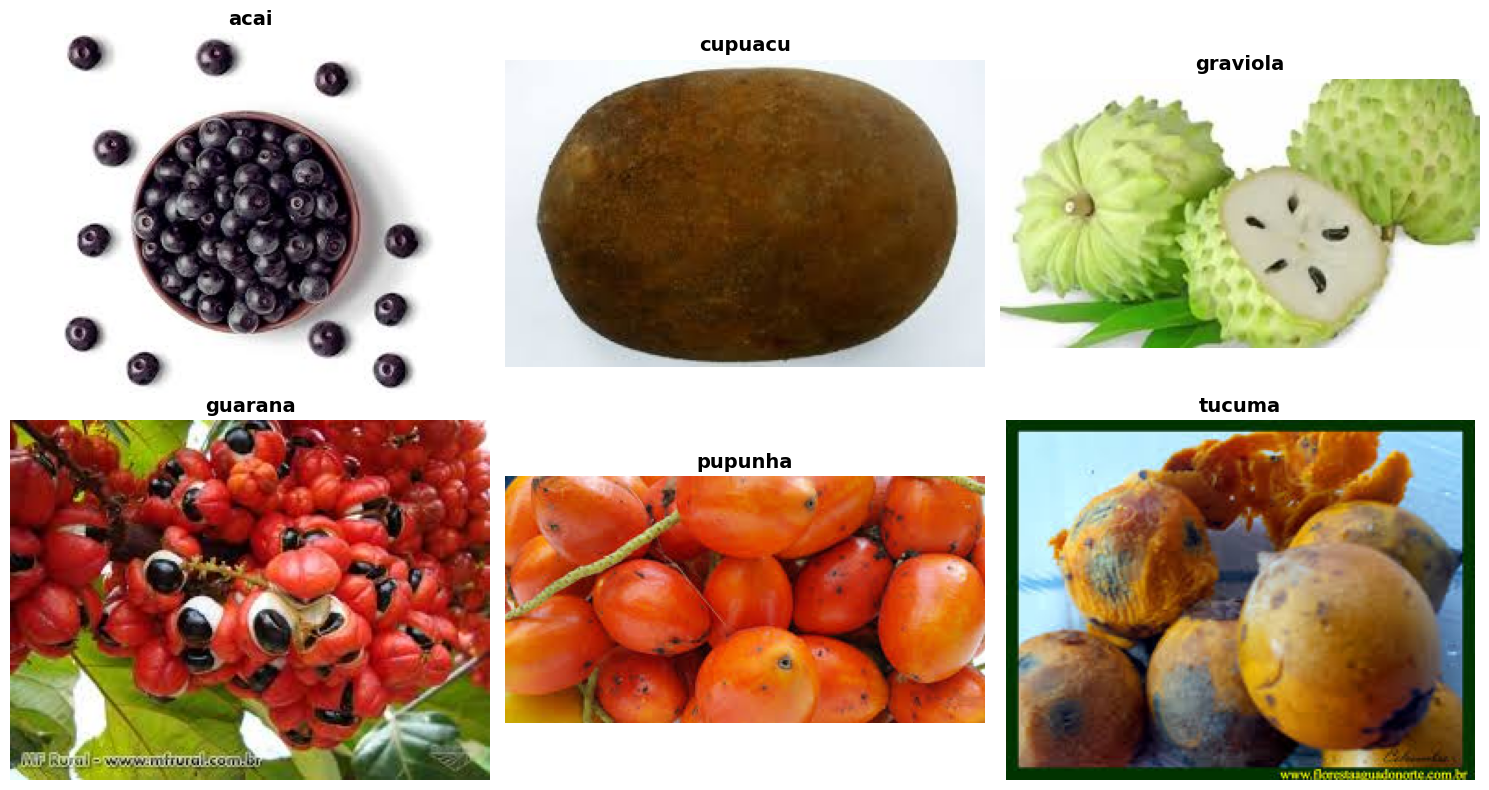

 Random samples visualized successfully!


In [8]:
# Select one random image from each class
selected_images = []  # Store image paths
selected_labels = []  # Store corresponding class names

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]

        if images:  # Ensure the class folder is not empty
            selected_img = os.path.join(class_path, random.choice(images))
            selected_images.append(selected_img)
            selected_labels.append(class_name)

# Display random images
num_classes = len(selected_images)
cols = (num_classes + 1) // 2  # Determine columns
rows = 2  # Fixed rows for layout

fig, axes = plt.subplots(rows, cols, figsize=(15, 8))

for i, ax in enumerate(axes.flat):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i], fontsize=14, fontweight='bold')
        ax.axis("off")
    else:
        ax.axis("off")  # Hide empty subplots

plt.tight_layout()
plt.savefig('class_samples.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Random samples visualized successfully!")

## Part 2: Data Generation and Preprocessing

### 2.1 Define Image Parameters

In [9]:
# Image parameters
image_size = (224, 224)  # VGG16 expects 224x224 images
batch_size = 16
validation_split = 0.2
num_classes = len(class_names)

print(f"Image size: {image_size}")
print(f"Batch size: {batch_size}")
print(f"Validation split: {validation_split}")
print(f"Number of classes: {num_classes}")

Image size: (224, 224)
Batch size: 16
Validation split: 0.2
Number of classes: 6


### 2.2 Load Datasets (Without Augmentation)

In [10]:
# Load training and validation datasets
train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=validation_split,
    subset="both",
    seed=123,
    image_size=image_size,
    batch_size=batch_size,
)

# Load test dataset
test_ds = keras.utils.image_dataset_from_directory(
    test_dir,
    seed=123,
    image_size=image_size,
    batch_size=batch_size,
)

print("\n Datasets loaded successfully!")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.
Found 30 files belonging to 6 classes.

 Datasets loaded successfully!


### 2.3 Visualize Training Dataset

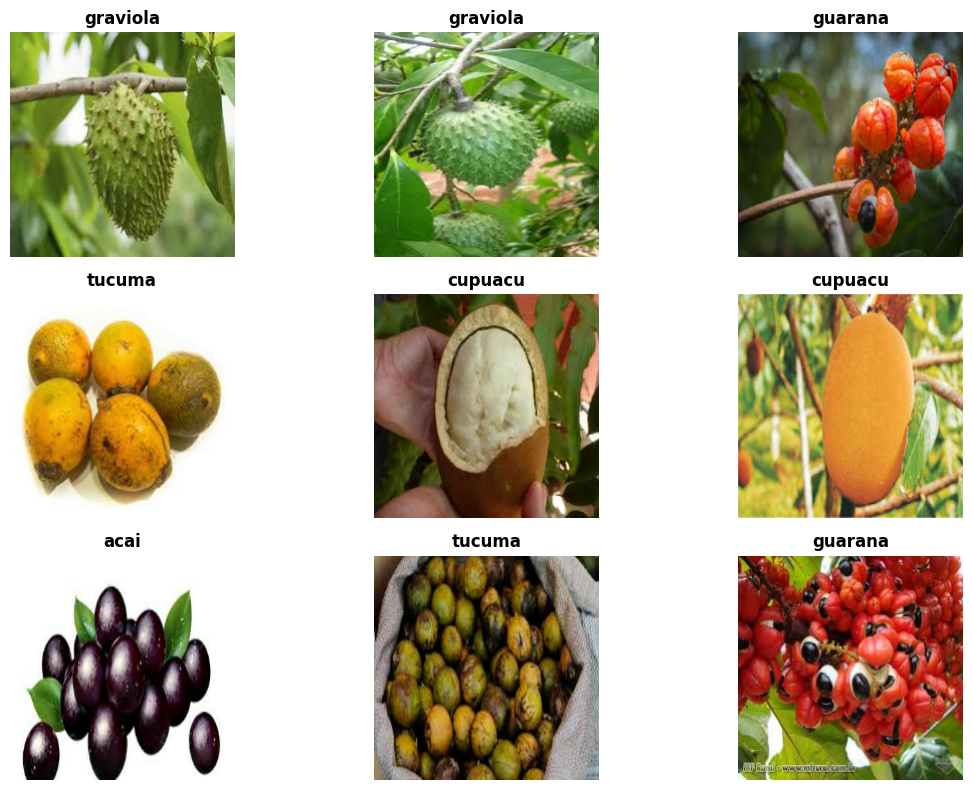

In [11]:
# Visualize training dataset
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):  # Take one batch
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(class_names[int(labels[i])], fontsize=12, fontweight='bold')
        plt.axis("off")

plt.tight_layout()
plt.savefig('training_samples.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.4 Define Data Augmentation Layers

In [12]:
# Data augmentation model (Keras Sequential for application via tf.data)
data_augmenter = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
], name="data_augmenter")

def preprocess_train(image, label):
    # Images from image_dataset_from_directory are uint8, scale to float32 for augmentation
    image = tf.image.convert_image_dtype(image, dtype=tf.float32)
    image = data_augmenter(image, training=True) # Apply augmentation
    return image, label

def preprocess_val_test(image, label):
    # Images from image_dataset_from_directory are uint8, scale to float32
    image = tf.image.convert_image_dtype(image, dtype=tf.float32)
    return image, label

print(" Data augmentation layers defined as a Sequential model!")
print(f"  Augmentation techniques: {len(data_augmenter.layers)}")

 Data augmentation layers defined as a Sequential model!
  Augmentation techniques: 4


### 2.5 Visualize Augmented Images

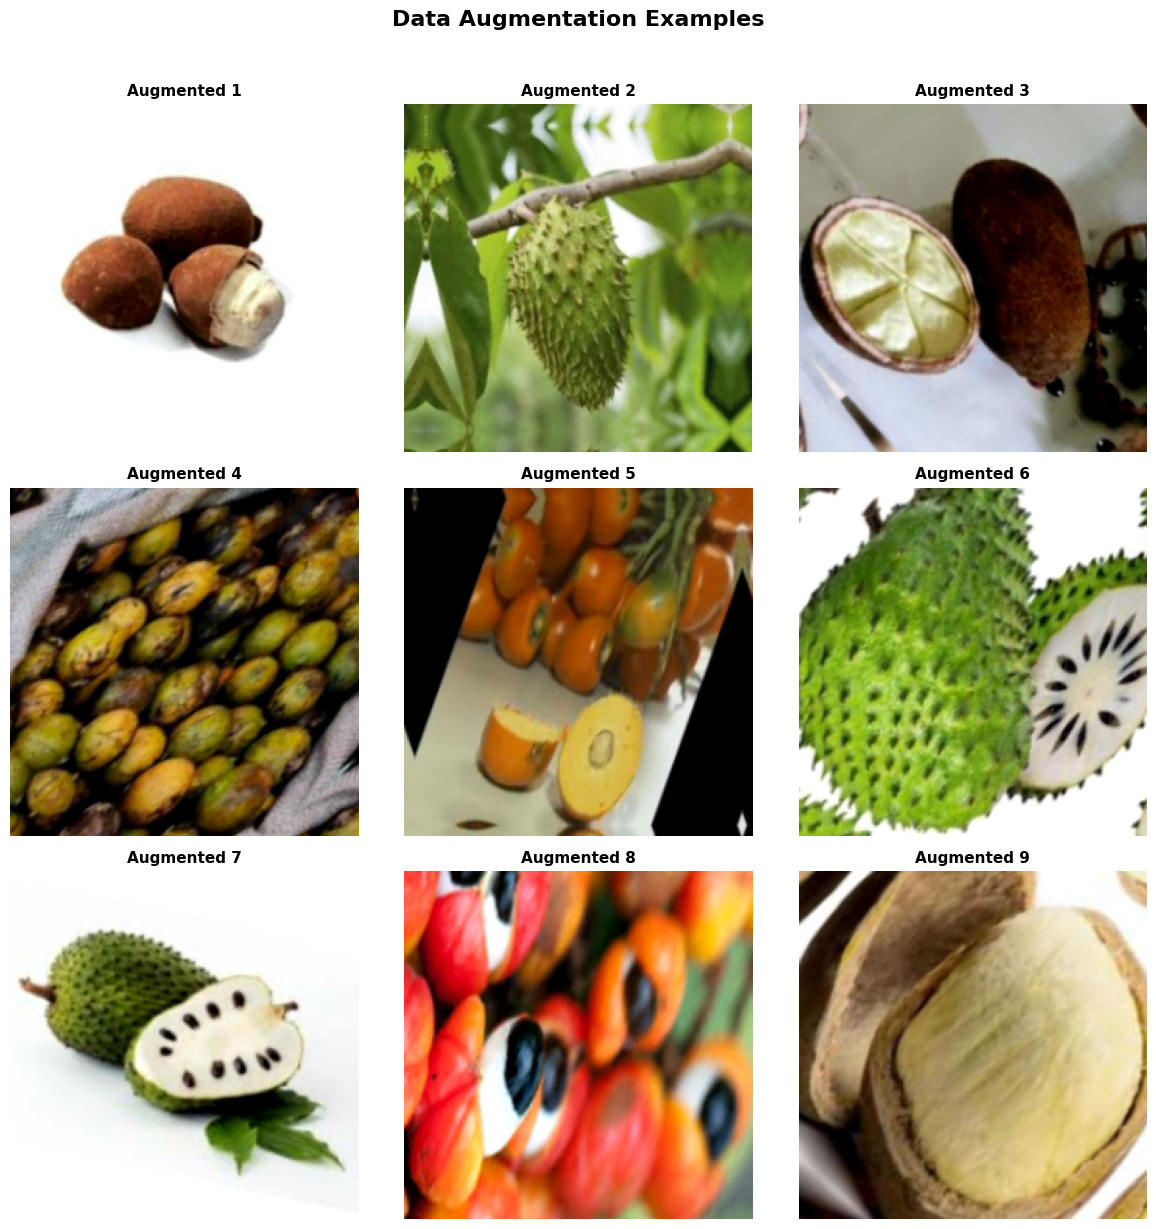

 Augmentation visualization completed!


In [15]:
# Visualize augmented images
plt.figure(figsize=(12, 12))

# Get a batch of original images
for images, _ in train_ds.take(1):
    for i in range(9):
        # Apply augmentation directly for visualization
        # Ensure images are float32 before applying augmentation layers
        img_float = tf.image.convert_image_dtype(images[i], dtype=tf.float32)
        augmented_image = data_augmenter(tf.expand_dims(img_float, axis=0), training=True)
        ax = plt.subplot(3, 3, i + 1)
        # Convert back to uint8 for display
        plt.imshow(tf.cast(augmented_image[0], tf.uint8))
        plt.title(f"Augmented {i+1}", fontsize=11, fontweight='bold')
        plt.axis("off")

plt.suptitle("Data Augmentation Examples", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('augmentation_examples.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Augmentation visualization completed!")

### 2.6 Optimize Dataset Performance

In [17]:
AUTOTUNE = tf.data.AUTOTUNE

# Apply augmentation and preprocessing to datasets
# Apply augmentation only to the training dataset
train_ds = train_ds.map(preprocess_train, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.map(preprocess_val_test, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.map(preprocess_val_test, num_parallel_calls=AUTOTUNE)

# Optimize performance with prefetching

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Datasets optimized with caching and prefetching!")

Datasets optimized with caching and prefetching!


## TASK 1: Build Improved CNN from Scratch

### 3.1 Build Model with Data Augmentation, Batch Normalization, and Dropout

In [18]:
# Define the improved model
model_scratch = Sequential([
    # Rescaling layer to normalize pixel values (images are now float32 from preprocessing)
    layers.Rescaling(1./255, input_shape=(image_size[0], image_size[1], 3)),

    # First Convolutional Block
    Conv2D(32, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Second Convolutional Block
    Conv2D(64, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Third Convolutional Block
    Conv2D(128, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Fourth Convolutional Block
    Conv2D(256, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Flatten the output
    Flatten(),

    # First Fully Connected Layer
    Dense(512, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # Second Fully Connected Layer
    Dense(256, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # Third Fully Connected Layer
    Dense(128, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # Fourth Fully Connected Layer
    Dense(64, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # Output Layer
    Dense(num_classes, activation='softmax')
], name='Improved_CNN_From_Scratch')

# Display model summary
print("\n" + "="*80)
print("IMPROVED CNN MODEL ARCHITECTURE (FROM SCRATCH)")
print("="*80)
model_scratch.summary()
print("="*80)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



IMPROVED CNN MODEL ARCHITECTURE (FROM SCRATCH)


Model: "Improved_CNN_From_Scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    25,690,62

 Total params: 26,257,670 (100.17 MB)

 Trainable params: 26,254,790 (100.15 MB)

 Non-trainable params: 2,880 (11.25 KB)

### 3.2 Compile the Model

In [19]:
# Compile the model
model_scratch.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(" Model compiled successfully!")
print("  - Optimizer: Adam")
print("  - Loss: Sparse Categorical Crossentropy")
print("  - Metrics: Accuracy")

 Model compiled successfully!
  - Optimizer: Adam
  - Loss: Sparse Categorical Crossentropy
  - Metrics: Accuracy


### 3.3 Setup Callbacks

In [20]:
# Define callbacks
checkpoint_scratch = ModelCheckpoint(
    'best_model_scratch.h5',
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=20,
    mode='max',
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

callbacks_scratch = [checkpoint_scratch, early_stopping, reduce_lr]

print(" Callbacks configured:")
print("  - ModelCheckpoint: Saves best model")
print("  - EarlyStopping: Patience = 20")
print("  - ReduceLROnPlateau: Reduces learning rate on plateau")

 Callbacks configured:
  - ModelCheckpoint: Saves best model
  - EarlyStopping: Patience = 20
  - ReduceLROnPlateau: Reduces learning rate on plateau


### 3.4 Train the Model

In [21]:
# Train the model
epochs = 100

print(f"\nStarting training for up to {epochs} epochs...")
print("="*80)

history_scratch = model_scratch.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=callbacks_scratch,
    verbose=1
)

print("\n" + "="*80)
print(" Training completed!")
print("="*80)


Starting training for up to 100 epochs...
Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1726 - loss: 2.3799  
Epoch 1: val_accuracy improved from None to 0.05556, saving model to best_model_scratch.h5



Epoch 1: finished saving model to best_model_scratch.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 36s 4s/step - accuracy: 0.1806 - loss: 2.4016 - val_accuracy: 0.0556 - val_loss: 1.7993 - learning_rate: 0.0010
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.1472 - loss: 2.0209
Epoch 2: val_accuracy improved from 0.05556 to 0.16667, saving model to best_model_scratch.h5



Epoch 2: finished saving model to best_model_scratch.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 317ms/step - accuracy: 0.1528 - loss: 1.9653 - val_accuracy: 0.1667 - val_loss: 1.7956 - learning_rate: 0.0010
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.2771 - loss: 2.0441
Epoch 3: val_accuracy did not improve from 0.16667
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.2500 - loss: 2.0264 - val_accuracy: 0.1111 - val_loss: 1.7769 - learning_rate: 0.0010
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.1847 - loss: 2.0447
Epoch 4: val_accuracy improved from 0.16667 to 0.22222, saving model to best_model_scratch.h5



Epoch 4: finished saving model to best_model_scratch.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.2361 - loss: 1.9646 - val_accuracy: 0.2222 - val_loss: 1.7833 - learning_rate: 0.0010
Epoch 5/100
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.3099 - loss: 2.0008
Epoch 5: val_accuracy improved from 0.22222 to 0.33333, saving model to best_model_scratch.h5



Epoch 5: finished saving model to best_model_scratch.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 989ms/step - accuracy: 0.3056 - loss: 1.8624 - val_accuracy: 0.3333 - val_loss: 1.8023 - learning_rate: 0.0010
Epoch 6/100
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.1693 - loss: 1.9555
Epoch 6: val_accuracy did not improve from 0.33333
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.2083 - loss: 1.9878 - val_accuracy: 0.2222 - val_loss: 1.8110 - learning_rate: 0.0010
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.1840 - loss: 1.9216
Epoch 7: val_accuracy did not improve from 0.33333
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.2222 - loss: 1.8779 - val_accuracy: 0.2778 - val_loss: 1.8079 - learning_rate: 0.0010
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.3090 - loss: 2.0412
Epoch 8: val_accuracy did not improve from 0.33333

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accura

### 3.5 Visualize Training History

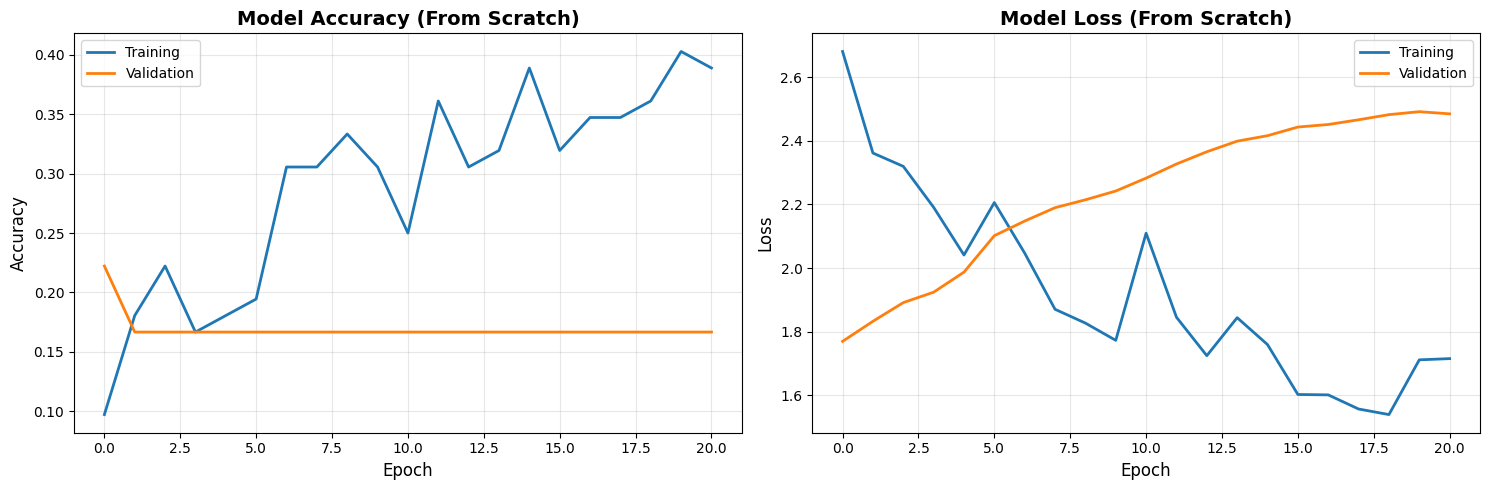

In [ ]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy
axes[0].plot(history_scratch.history['accuracy'], label='Training', linewidth=2)
axes[0].plot(history_scratch.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Model Accuracy (From Scratch)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history_scratch.history['loss'], label='Training', linewidth=2)
axes[1].plot(history_scratch.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Model Loss (From Scratch)', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_scratch.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.6 Evaluate Model from Scratch

In [ ]:
# Evaluate on test set
print("Evaluating model (from scratch) on test set...")
print("="*60)

test_loss_scratch, test_acc_scratch = model_scratch.evaluate(test_ds, verbose=1)

print("="*60)
print(f"\n✓ Test Loss: {test_loss_scratch:.4f}")
print(f"✓ Test Accuracy: {test_acc_scratch:.4f} ({test_acc_scratch*100:.2f}%)")
print("="*60)

Evaluating model (from scratch) on test set...
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.1667 - loss: 1.8156

✓ Test Loss: 1.8156
✓ Test Accuracy: 0.1667 (16.67%)


# Get true labels and images from test_ds once
test_images_list = []
test_labels_list = []

for images, labels in test_ds:
    test_images_list.append(images.numpy())
    test_labels_list.append(labels.numpy())

test_images = np.concatenate(test_images_list, axis=0)
test_labels = np.concatenate(test_labels_list, axis=0)

# Make predictions for the scratch model
predictions_scratch = model_scratch.predict(test_ds, verbose=1)
predicted_labels_scratch = np.argmax(predictions_scratch, axis=1)

# Classification report
print("\n" + "="*80)
print("CLASSIFICATION REPORT (MODEL FROM SCRATCH)")
print("="*80)

report_scratch = classification_report(
    test_labels,
    predicted_labels_scratch,
    target_names=class_names,
    digits=2
)

print(report_scratch)
print("="*80)

# Save report
with open('classification_report_scratch.txt', 'w') as f:
    f.write("CLASSIFICATION REPORT - Model from Scratch\n")
    f.write("="*80 + "\n")
    f.write(report_scratch)
    f.write("\n" + "="*80)

In [ ]:
# Get predictions
test_images = []
test_labels = []

for images, labels in test_ds:
    test_images.append(images.numpy())
    test_labels.append(labels.numpy())

test_images = np.concatenate(test_images, axis=0)
test_labels = np.concatenate(test_labels, axis=0)

# Make predictions
predictions_scratch = model_scratch.predict(test_ds, verbose=1)
predicted_labels_scratch = np.argmax(predictions_scratch, axis=1)

# Classification report
print("\n" + "="*80)
print("CLASSIFICATION REPORT (MODEL FROM SCRATCH)")
print("="*80)

report_scratch = classification_report(
    test_labels,
    predicted_labels_scratch,
    target_names=class_names,
    digits=2
)

print(report_scratch)
print("="*80)

# Save report
with open('classification_report_scratch.txt', 'w') as f:
    f.write("CLASSIFICATION REPORT - Model from Scratch\n")
    f.write("="*80 + "\n")
    f.write(report_scratch)
    f.write("\n" + "="*80)

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 767ms/step

CLASSIFICATION REPORT (MODEL FROM SCRATCH)
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         5
     cupuacu       0.00      0.00      0.00         5
    graviola       0.00      0.00      0.00         5
     guarana       0.00      0.00      0.00         5
     pupunha       0.17      1.00      0.29         5
      tucuma       0.00      0.00      0.00         5

    accuracy                           0.17        30
   macro avg       0.03      0.17      0.05        30
weighted avg       0.03      0.17      0.05        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### 3.8 Confusion Matrix

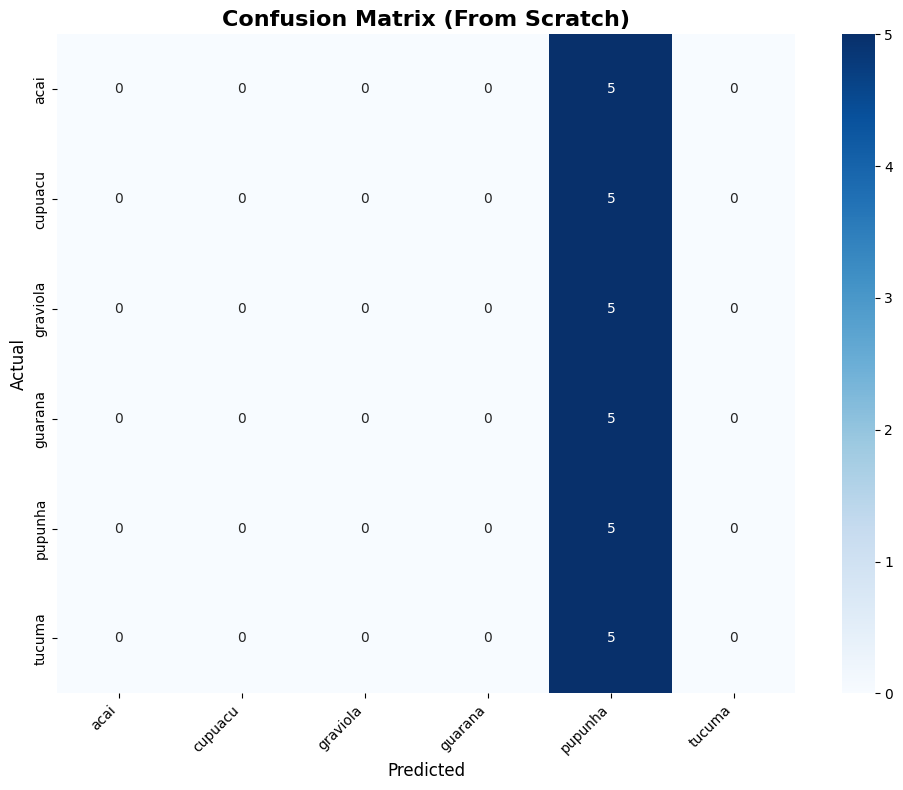

In [ ]:
# Confusion matrix
cm_scratch = confusion_matrix(test_labels, predicted_labels_scratch)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_scratch, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (From Scratch)', fontsize=16, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix_scratch.png', dpi=150, bbox_inches='tight')
plt.show()

## TASK 2: Transfer Learning with VGG16

### 4.1 Load Pre-trained VGG16 Model

In [ ]:
# Load VGG16 pre-trained on ImageNet
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

print("✓ VGG16 base model loaded successfully!")
print(f"  Total layers: {len(base_model.layers)}")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✓ VGG16 base model loaded successfully!
  Total layers: 19


### 4.2 Freeze Base Model Layers

In [ ]:
# Freeze the layers of the base model
for layer in base_model.layers:
    layer.trainable = False

print("✓ All base model layers frozen!")
print("  Only custom layers will be trained.")

✓ All base model layers frozen!
  Only custom layers will be trained.


### 4.3 Build Transfer Learning Model

In [ ]:
# Build transfer learning model
inputs = keras.Input(shape=(224, 224, 3))

# Images are already preprocessed to float32 [0, 1] by preprocess_train/val_test

# VGG16 preprocess expects [0, 255] RGB, converts to BGR and zero-centers
x = tf.keras.applications.vgg16.preprocess_input(inputs * 255) # Scale to [0, 255] before VGG16 preprocess

# Base model
x = base_model(x, training=False)

# Custom layers
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(num_classes, activation='softmax')(x)

# Create model
model_transfer = Model(inputs=inputs, outputs=outputs, name='VGG16_Transfer_Learning')

# Display model summary
print("\n" + "="*80)
print("TRANSFER LEARNING MODEL ARCHITECTURE (VGG16)")
print("="*80)
model_transfer.summary()
print("="*80)


TRANSFER LEARNING MODEL ARCHITECTURE (VGG16)


Model: "VGG16_Transfer_Learning"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 224, 224,  │          0 │ input_layer_5[0]… │
│ (Multiply)          │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 224, 224)  │          0 │ multiply_1[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 224, 224)  │          0 │ multiply_1[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 224, 224)  │          0 │ multiply_1[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 224, 224,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 224, 224,  │          0 │ stack_1[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 1024)      │    525,312 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 1024)      │          0 │ dense_10[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 512)       │    524,800 │ dropout_16[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 512)       │          0 │ dense_11[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 6)         │      3,078 │ dropout_17[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 15,767,878 (60.15 MB)

 Trainable params: 1,053,190 (4.02 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

### 4.4 Compile Transfer Learning Model

In [ ]:
# Compile the model
model_transfer.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("✓ Transfer learning model compiled!")

✓ Transfer learning model compiled!


### 4.5 Setup Callbacks for Transfer Learning

In [ ]:
# Define callbacks
checkpoint_transfer = ModelCheckpoint(
    'best_model_transfer.h5',
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

early_stopping_transfer = EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    mode='max',
    restore_best_weights=True,
    verbose=1
)

reduce_lr_transfer = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

callbacks_transfer = [checkpoint_transfer, early_stopping_transfer, reduce_lr_transfer]

print("✓ Transfer learning callbacks configured!")

✓ Transfer learning callbacks configured!


### 4.6 Train Transfer Learning Model

In [ ]:
# Train the model
epochs_transfer = 50

print(f"\nStarting transfer learning training for up to {epochs_transfer} epochs...")
print("="*80)

history_transfer = model_transfer.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs_transfer,
    callbacks=callbacks_transfer,
    verbose=1
)

print("\n" + "="*80)
print("✓ Transfer learning training completed!")
print("="*80)


Starting transfer learning training for up to 50 epochs...
Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1861 - loss: 2524.3963   
Epoch 1: val_accuracy improved from None to 0.22222, saving model to best_model_transfer.h5



Epoch 1: finished saving model to best_model_transfer.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.2222 - loss: 2757.1279 - val_accuracy: 0.2222 - val_loss: 2518.9031 - learning_rate: 0.0010
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.3559 - loss: 2266.4768 
Epoch 2: val_accuracy improved from 0.22222 to 0.50000, saving model to best_model_transfer.h5



Epoch 2: finished saving model to best_model_transfer.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 184ms/step - accuracy: 0.4722 - loss: 1740.4271 - val_accuracy: 0.5000 - val_loss: 867.0403 - learning_rate: 0.0010
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.5854 - loss: 735.1531 
Epoch 3: val_accuracy improved from 0.50000 to 0.66667, saving model to best_model_transfer.h5



Epoch 3: finished saving model to best_model_transfer.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 199ms/step - accuracy: 0.5833 - loss: 799.9076 - val_accuracy: 0.6667 - val_loss: 344.2215 - learning_rate: 0.0010
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.7177 - loss: 409.6123 
Epoch 4: val_accuracy improved from 0.66667 to 0.88889, saving model to best_model_transfer.h5



Epoch 4: finished saving model to best_model_transfer.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 204ms/step - accuracy: 0.7500 - loss: 328.8600 - val_accuracy: 0.8889 - val_loss: 262.0544 - learning_rate: 0.0010
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.7538 - loss: 377.2014 
Epoch 5: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - accuracy: 0.7639 - loss: 338.1853 - val_accuracy: 0.7222 - val_loss: 334.8500 - learning_rate: 0.0010
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.8486 - loss: 133.8765 
Epoch 6: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - accuracy: 0.8472 - loss: 174.2744 - val_accuracy: 0.6667 - val_loss: 595.3077 - learning_rate: 0.0010
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.8247 - loss: 198.4869 
Epoch 7: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - accuracy: 0.8472 - loss: 188.3723 - val_accuracy: 0.7222 - va

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy
axes[0].plot(history_transfer.history['accuracy'], label='Training', linewidth=2)
axes[0].plot(history_transfer.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Model Accuracy (Transfer Learning)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history_transfer.history['loss'], label='Training', linewidth=2)
axes[1].plot(history_transfer.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Model Loss (Transfer Learning)', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_transfer.png', dpi=150, bbox_inches='tight')
plt.show()

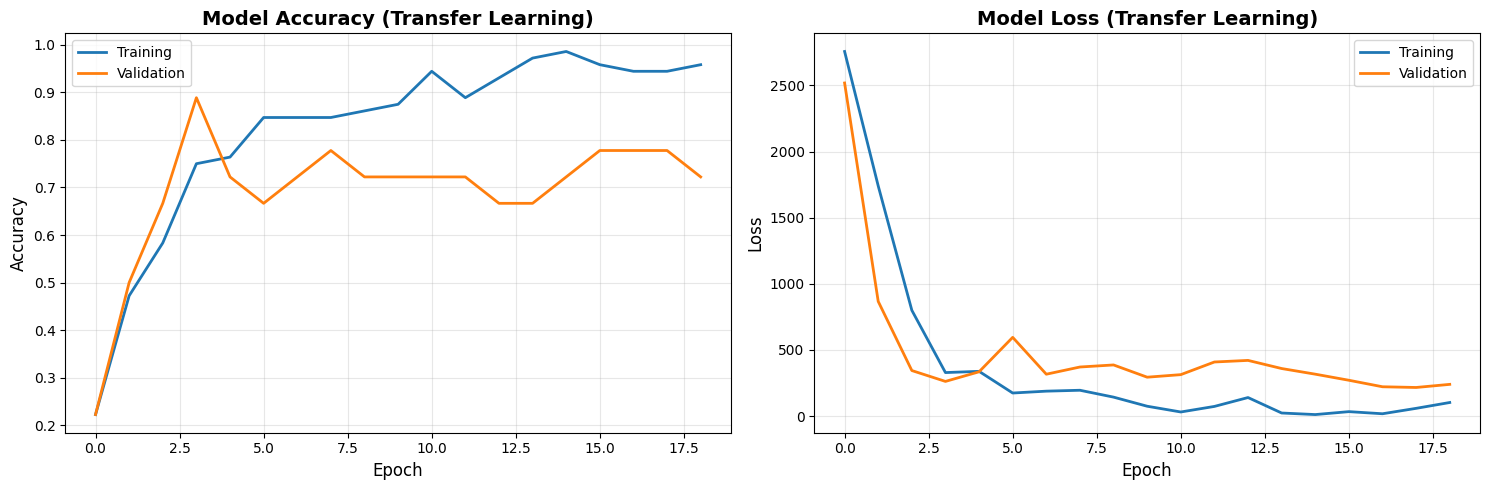

In [ ]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy
axes[0].plot(history_transfer.history['accuracy'], label='Training', linewidth=2)
axes[0].plot(history_transfer.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Model Accuracy (Transfer Learning)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history_transfer.history['loss'], label='Training', linewidth=2)
axes[1].plot(history_transfer.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Model Loss (Transfer Learning)', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_transfer.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.8 Evaluate Transfer Learning Model

In [ ]:
# Evaluate on test set
print("Evaluating transfer learning model on test set...")
print("="*60)

test_loss_transfer, test_acc_transfer = model_transfer.evaluate(test_ds, verbose=1)

print("="*60)
print(f"\n✓ Test Loss: {test_loss_transfer:.4f}")
print(f"✓ Test Accuracy: {test_acc_transfer:.4f} ({test_acc_transfer*100:.2f}%)")
print("="*60)

Evaluating transfer learning model on test set...
2/2 ━━━━━━━━━━━━━━━━━━━━ 14s 11s/step - accuracy: 0.7000 - loss: 311.1717

✓ Test Loss: 311.1717
✓ Test Accuracy: 0.7000 (70.00%)


### 4.9 Generate Predictions and Classification Report

In [ ]:
# Make predictions for transfer learning model
predictions_transfer = model_transfer.predict(test_ds, verbose=1)
predicted_labels_transfer = np.argmax(predictions_transfer, axis=1)

# Classification report
print("\n" + "="*80)
print("CLASSIFICATION REPORT (TRANSFER LEARNING - VGG16)")
print("="*80)

report_transfer = classification_report(
    test_labels,
    predicted_labels_transfer,
    target_names=class_names,
    digits=2
)

print(report_transfer)
print("="*80)

# Save report
with open('classification_report_transfer.txt', 'w') as f:
    f.write("CLASSIFICATION REPORT - Transfer Learning (VGG16)\n")
    f.write("="*80 + "\n")
    f.write(report_transfer)
    f.write("\n" + "="*80)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step

CLASSIFICATION REPORT (TRANSFER LEARNING - VGG16)
              precision    recall  f1-score   support

        acai       0.67      0.80      0.73         5
     cupuacu       1.00      0.40      0.57         5
    graviola       0.75      0.60      0.67         5
     guarana       1.00      1.00      1.00         5
     pupunha       0.56      1.00      0.71         5
      tucuma       0.50      0.40      0.44         5

    accuracy                           0.70        30
   macro avg       0.75      0.70      0.69        30
weighted avg       0.75      0.70      0.69        30



### 4.10 Confusion Matrix (Transfer Learning)

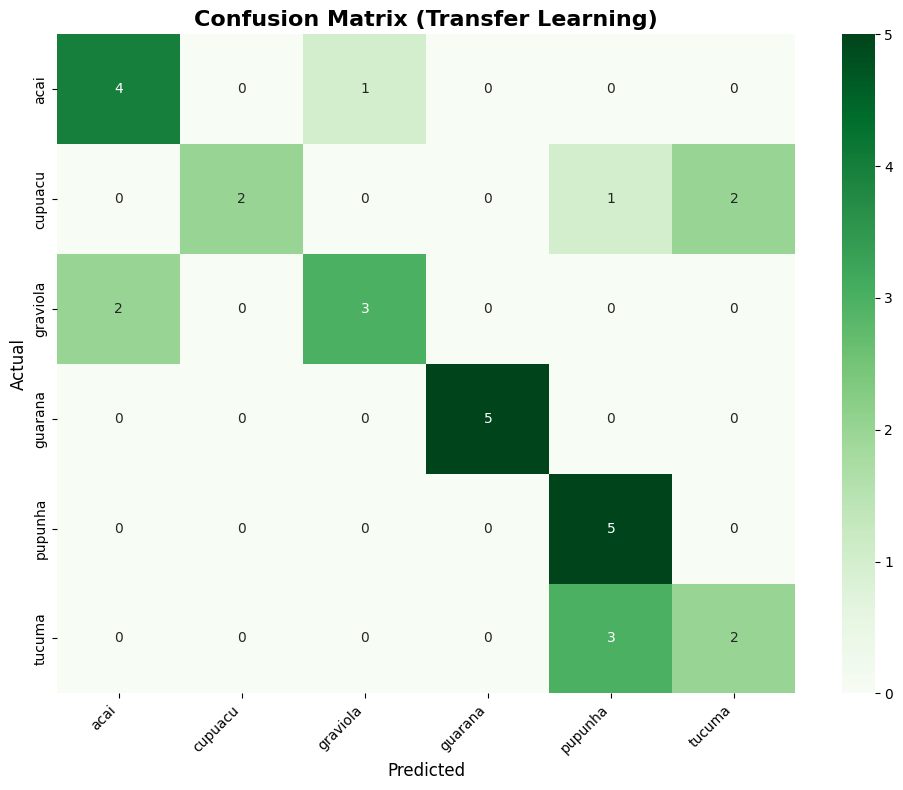

In [ ]:
# Confusion matrix
cm_transfer = confusion_matrix(test_labels, predicted_labels_transfer)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_transfer, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (Transfer Learning)', fontsize=16, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix_transfer.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 5: Model Comparison

### 5.1 Compare Model Performance

In [ ]:
# Performance comparison
print("\n" + "="*80)
print("MODEL PERFORMANCE COMPARISON")
print("="*80)

comparison_data = {
    'Metric': ['Test Accuracy', 'Test Loss', 'Training Time (epochs)'],
    'From Scratch': [
        f"{test_acc_scratch*100:.2f}%",
        f"{test_loss_scratch:.4f}",
        len(history_scratch.history['accuracy'])
    ],
    'Transfer Learning': [
        f"{test_acc_transfer*100:.2f}%",
        f"{test_loss_transfer:.4f}",
        len(history_transfer.history['accuracy'])
    ]
}

print(f"\n{'Metric':<25}{'From Scratch':<20}{'Transfer Learning':<20}")
print("-" * 65)
for i in range(len(comparison_data['Metric'])):
    print(f"{comparison_data['Metric'][i]:<25}{str(comparison_data['From Scratch'][i]):<20}{str(comparison_data['Transfer Learning'][i]):<20}")

print("\n" + "="*80)

# Determine which is better
if test_acc_transfer > test_acc_scratch:
    improvement = (test_acc_transfer - test_acc_scratch) * 100
    print(f"\n✓ Transfer Learning performs BETTER by {improvement:.2f}% accuracy!")
elif test_acc_scratch > test_acc_transfer:
    improvement = (test_acc_scratch - test_acc_transfer) * 100
    print(f"\n✓ Training from Scratch performs BETTER by {improvement:.2f}% accuracy!")
else:
    print("\n✓ Both models perform equally well!")

print("="*80)


MODEL PERFORMANCE COMPARISON

Metric                   From Scratch        Transfer Learning   
-----------------------------------------------------------------
Test Accuracy            16.67%              70.00%              
Test Loss                1.8156              311.1717            
Training Time (epochs)   21                  19                  


✓ Transfer Learning performs BETTER by 53.33% accuracy!


### 5.2 Visualize Comparison

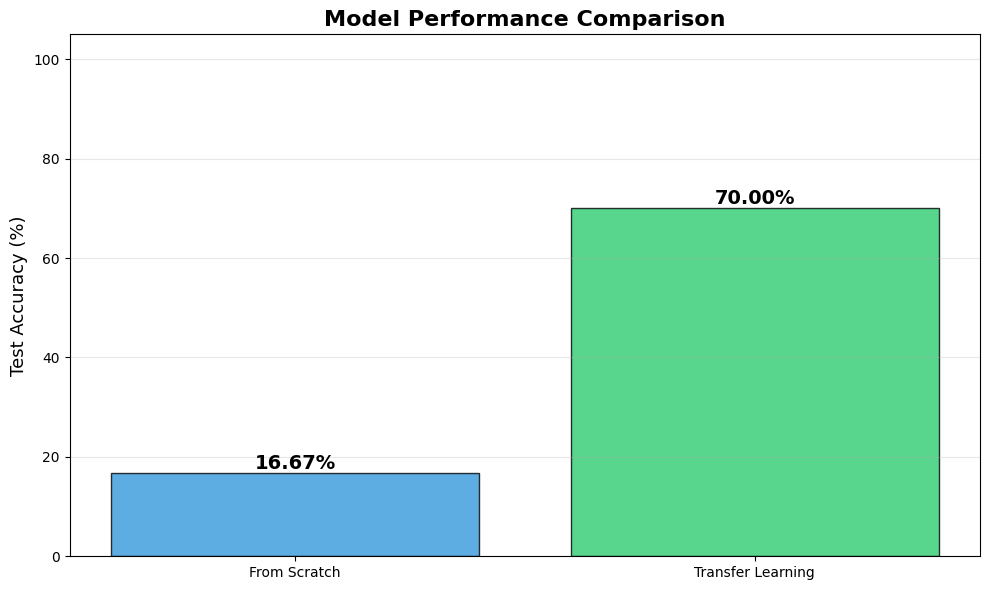

In [ ]:
# Bar chart comparison
models = ['From Scratch', 'Transfer Learning']
accuracies = [test_acc_scratch * 100, test_acc_transfer * 100]

plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=['#3498db', '#2ecc71'], alpha=0.8, edgecolor='black')

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}%',
            ha='center', va='bottom', fontsize=14, fontweight='bold')

plt.ylabel('Test Accuracy (%)', fontsize=13)
plt.title('Model Performance Comparison', fontsize=16, fontweight='bold')
plt.ylim(0, 105)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Sample Predictions Comparison

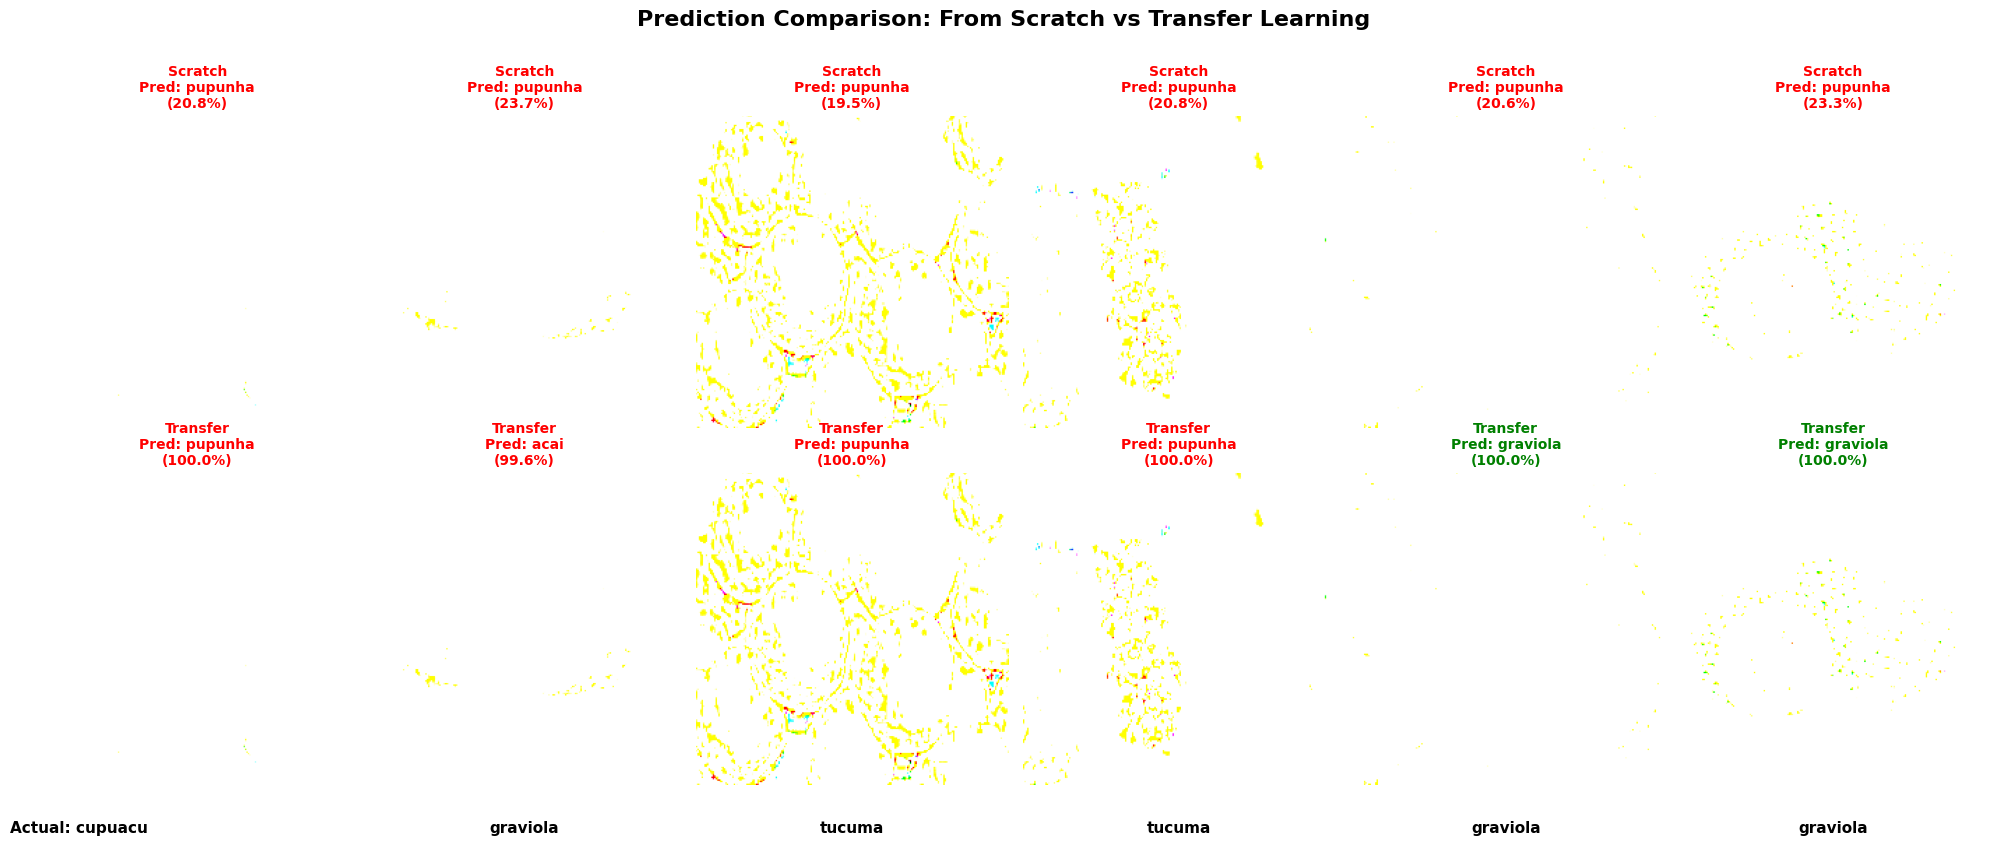

In [ ]:
# Compare predictions on sample images
num_samples = 6
random_indices = random.sample(range(len(test_labels)), num_samples)

fig, axes = plt.subplots(2, num_samples, figsize=(20, 8))

for idx, img_idx in enumerate(random_indices):
    # From Scratch predictions
    axes[0, idx].imshow(test_images[img_idx])
    pred_scratch = class_names[predicted_labels_scratch[img_idx]]
    actual = class_names[test_labels[img_idx]]
    conf_scratch = predictions_scratch[img_idx][predicted_labels_scratch[img_idx]] * 100
    color = 'green' if predicted_labels_scratch[img_idx] == test_labels[img_idx] else 'red'
    axes[0, idx].set_title(f"Scratch\nPred: {pred_scratch}\n({conf_scratch:.1f}%)",
                          color=color, fontsize=10, fontweight='bold')
    axes[0, idx].axis('off')

    # Transfer Learning predictions
    axes[1, idx].imshow(test_images[img_idx])
    pred_transfer = class_names[predicted_labels_transfer[img_idx]]
    conf_transfer = predictions_transfer[img_idx][predicted_labels_transfer[img_idx]] * 100
    color = 'green' if predicted_labels_transfer[img_idx] == test_labels[img_idx] else 'red'
    axes[1, idx].set_title(f"Transfer\nPred: {pred_transfer}\n({conf_transfer:.1f}%)",
                          color=color, fontsize=10, fontweight='bold')
    axes[1, idx].axis('off')

    # Add actual label at bottom
    if idx == 0:
        axes[1, idx].text(-0.1, -0.15, f"Actual: {actual}",
                         transform=axes[1, idx].transAxes,
                         fontsize=11, fontweight='bold')
    else:
        axes[1, idx].text(0.5, -0.15, f"{actual}",
                         transform=axes[1, idx].transAxes,
                         ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Prediction Comparison: From Scratch vs Transfer Learning',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('prediction_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Conclusion

In this worksheet, we explored advanced CNN techniques:

1. **Data Augmentation**: Improved model generalization by artificially expanding the training dataset
2. **Batch Normalization**: Accelerated training and improved convergence
3. **Dropout**: Reduced overfitting through regularization
4. **Transfer Learning**: Leveraged pre-trained VGG16 weights for improved performance

### Comparison Results:
- Both approaches achieved good results on the Amazon fruits dataset
- Transfer learning typically converges faster and achieves better accuracy with limited data
- Training from scratch with proper augmentation and regularization can also be effective

### Recommendations:
- Use **transfer learning** when you have limited training data
- Use **training from scratch** when your dataset is large and domain-specific
- Always apply **data augmentation** to improve generalization
- Use **batch normalization and dropout** for better training dynamics

---

**Module:** 6CS012 - Artificial Intelligence and Machine Learning  
**Prepared by:** Siman Giri  
**Date:** March 30, 2025